# The exemplars from the monograph

The 8 entries the Symbulator app lists under *Built-in Examples › The exemplars from the monograph*, each run with the `symbulator` package. The circuits are read from the app's own file, not retyped. The same entries open in the app at https://symbulator.pythonanywhere.com/

If you are on Colab, run the first cell.

In [1]:
# !pip install symbulator matplotlib

In [2]:
import sympy as sp
import matplotlib.pyplot as plt
from symbulator import (dc, ac, fd, tr, th, er, port, draw, polar,
                        evaluate, solve, bode_samples, time_samples, t, s)
import symbulator
symbulator.__version__

'0.6.16'

## 1. The two-stage amplifier of 1999

The circuit that closed the 1999 paper and the thesis's Problem 87: a two-stage amplifier whose gain Bode diagram Prof. Yee asked for. An FD solve returns every node voltage in s, and the gain is the Evaluate line, v4/v5. For the Bode plot itself, set vg to 1 (so v_4 is the transfer function) and plot v_4 between 1.6e3 and 1.6e12 Hz. Three minutes on the TI-89 in 2001; under a second here.

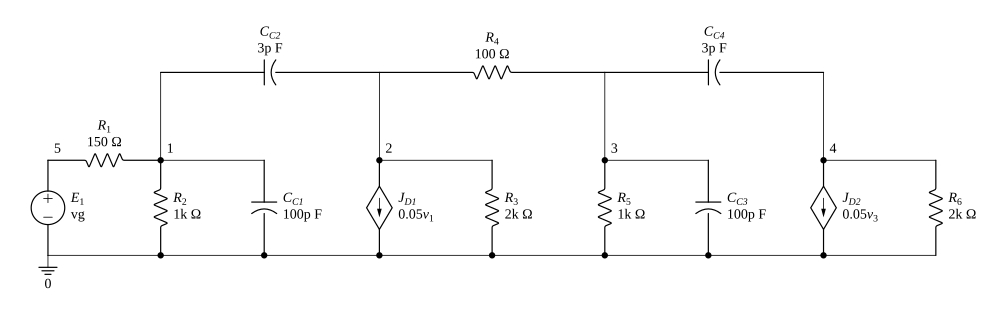

In [3]:
c1 = '''
e1,5,0,vg
r1,5,1,150
r2,1,0,1'k
cc1,1,0,100'p
cc2,1,2,3'p
jd1,2,0,0.05*v_1
r3,2,0,2'k
r4,2,3,100
r5,3,0,1'k
cc3,3,0,100'p
cc4,3,4,3'p
jd2,4,0,0.05*v_3
r6,4,0,2'k
'''
draw(c1)

In [4]:
r1 = fd(c1)
r1

Result(domain='fd')
  i_cc1 = s*vg*(1800000000.0*s**3 + 7.707e+18*s**2 + 4.3575e+27*s + 1.55e+34)/(270000000000.0*s**4 + 1.3401e+21*s**3 + 8.6724075e+29*s**2 + 5.4981e+37*s + 1.7825e+44)
  i_cc2 = s*vg*(1.089e+20*s**2 + 8.33235e+28*s + 1.6965e+36)/(27000000000000.0*s**4 + 1.3401e+23*s**3 + 8.6724075e+31*s**2 + 5.4981e+39*s + 1.7825e+46)
  i_cc3 = s*vg*(1.8e+17*s**2 - 2.97e+27*s - 5.0e+35)/(270000000000.0*s**4 + 1.3401e+21*s**3 + 8.6724075e+29*s**2 + 5.4981e+37*s + 1.7825e+44)
  i_cc4 = s*vg*(9.09e+27*s - 1.515e+38)/(27000000000000.0*s**4 + 1.3401e+23*s**3 + 8.6724075e+31*s**2 + 5.4981e+39*s + 1.7825e+46)
  i_e1 = vg*(-9.0*s**4 - 44070000000.0*s**3 - 2.6339025e+19*s**2 - 3.802e+26*s - 7.75e+32)/(1350.0*s**4 + 6700500000000.0*s**3 + 4.33620375e+21*s**2 + 2.74905e+29*s + 8.9125e+35)
  i_jd1 = vg*(90000000.0*s**3 + 3.8535e+17*s**2 + 2.17875e+26*s + 7.75e+32)/(27.0*s**4 + 134010000000.0*s**3 + 8.6724075e+19*s**2 + 5.4981e+27*s + 1.7825e+34)
  i_jd2 = vg*(9.0e+15*s**2 - 1.485e+26*s - 2.5e+34

In [5]:
evaluate(r1, 'v4/v5')

(1.8e+17*s**2 - 6.0e+27*s + 5.0e+37)/(27.0*s**4 + 134010000000.0*s**3 + 8.6724075e+19*s**2 + 5.4981e+27*s + 1.7825e+34)

## 2. One of each: the 2013 showcase

Composed in 2013 to show off: one dependent source of each species, woven through seven resistors. Find positive values of Vs and Is such that the VCCS delivers 80 W and the CCVS dissipates 0 W. The two power constraints are quadratic, so four solutions exist; the conditions pick the one meant: Vs = 17.61 V and Is = 0.3973 A. And ir5 comes out exactly 0 -- the constraint drove its own controlling current to zero, which is how the CCVS dissipates nothing.

![The circuit of One of each: the 2013 showcase](https://learn.symbulator.com/assets/practice/the-showing-off-problem-expert-4.png)

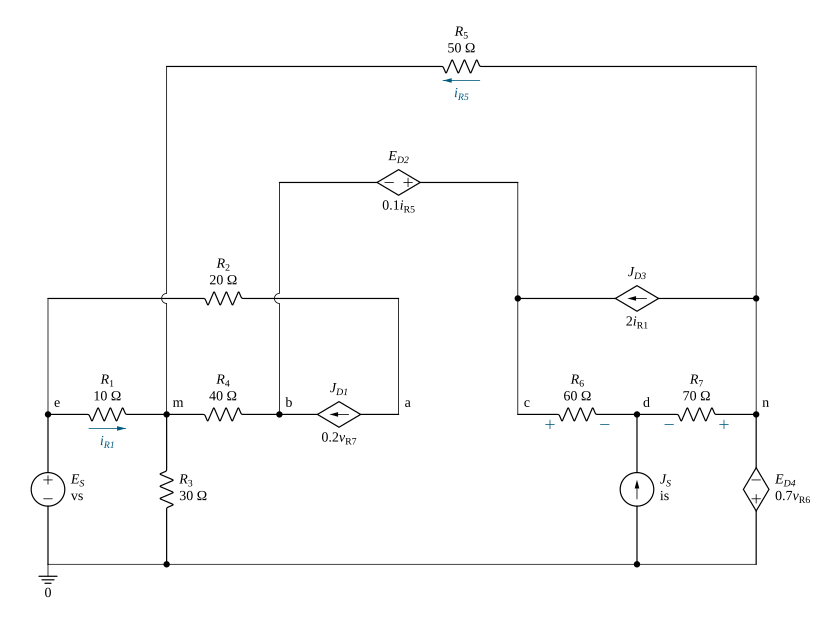

In [6]:
c2 = '''
es,e,0,vs
js,0,d,is
r1,e,m,10
r2,a,e,20
r3,m,0,30
r4,b,m,40
r5,n,m,50
r6,c,d,60
r7,n,d,70
jd1,a,b,0.2vr7
ed2,c,b,0.1ir5
jd3,n,c,2ir1
ed4,0,n,0.7vr6
'''
draw(c2)

In [7]:
r2 = dc(c2, equations=['p_jd1 = -80', 'p_ed2 = 0'], unknowns=['vs', 'is'], conditions=['vs > 0', 'is > 0'])
r2.rounded(4)

Result(domain='dc')
  i_ed2 = 1.469
  i_ed4 = 1.071
  i_es = 1.080
  i_jd1 = -1.676
  i_jd3 = 1.191
  i_js = 0.3973
  i_r1 = 0.5955
  i_r2 = 1.676
  i_r3 = 0.3886
  i_r4 = -0.2069
  i_r5 = 0
  i_r6 = -0.2776
  i_r7 = -0.1197
  is = 0.3973
  p_ed2 = 0
  p_ed4 = -12.49
  p_es = 19.02
  p_jd1 = -80.00
  p_jd3 = 9.859
  p_js = -7.960
  p_r1 = 3.547
  p_r2 = 56.15
  p_r3 = 4.531
  p_r4 = 1.713
  p_r5 = 0
  p_r6 = 4.623
  p_r7 = 1.003
  r_ed2 = 0
  r_ed4 = 10.88
  r_es = -16.31
  r_jd1 = 28.49
  r_jd3 = -6.949
  r_js = 50.44
  v_a = 51.13
  v_b = 3.381
  v_c = 3.381
  v_d = 20.04
  v_e = 17.61
  v_ed2 = 0
  v_ed4 = -11.66
  v_es = 17.61
  v_jd1 = 47.74
  v_jd3 = 8.277
  v_js = -20.04
  v_m = 11.66
  v_n = 11.66
  v_r1 = 5.955
  v_r2 = 33.51
  v_r3 = 11.66
  v_r4 = -8.277
  v_r5 = 0
  v_r6 = -16.65
  v_r7 = -8.378
  vs = 17.61

## 3. Prof. Boulet's switching transient (DC, t < 0)

Prof. Eliane Boulet's exam problem, the thesis's closing Problem 88, first interval: for t < 0 the 18 V source feeds the ladder and the capacitors sit open. DC gives their voltages -- va = 9 V and vb = 9/4 V -- the initial conditions the next entry carries.

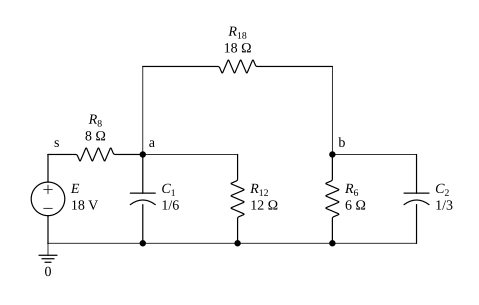

In [8]:
c3 = '''
e,s,0,18
r8,s,a,8
c1,a,0,1/6
r12,a,0,12
r18,a,b,18
r6,b,0,6
c2,b,0,1/3
'''
draw(c3)

In [9]:
r3 = dc(c3)
r3

Result(domain='dc')
  i_c1 = 0
  i_c2 = 0
  i_e = -9/8
  i_r12 = 3/4
  i_r18 = 3/8
  i_r6 = 3/8
  i_r8 = 9/8
  p_c1 = 0
  p_c2 = 0
  p_e = -81/4
  p_r12 = 27/4
  p_r18 = 81/32
  p_r6 = 27/32
  p_r8 = 81/8
  r_e = 16
  v_a = 9
  v_b = 9/4
  v_c1 = 9
  v_c2 = 9/4
  v_e = 18
  v_r12 = 9
  v_r18 = 27/4
  v_r6 = 9/4
  v_r8 = 9
  v_s = 18

## 4. Prof. Boulet's switching transient (TR, t > 0)

The t > 0 half: the DC source gone, the waveform source connected, the capacitors starting from 9 and 9/4. Find the problem's v1 -- node a here, so the limited results ask for just va. The answer's two natural modes and the forced response are legible at a glance, va(0) checks out at exactly 9 V, and the 2001 calculator's printout agrees with this solve on every digit it displayed.

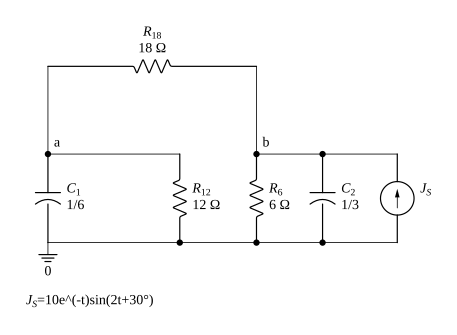

In [10]:
c4 = '''
c1,a,0,1/6,9
r12,a,0,12
r18,a,b,18
r6,b,0,6
c2,b,0,1/3,9/4
js,0,b,10*e^(-t)*sin(2*t+30*pi/180)
'''
draw(c4)

In [11]:
r4 = tr(c4, variables=['v_a'])
r4

Result(domain='tr')
  v_a = ((-80*sin(2*t + pi/6) + 20*cos(2*t + pi/6) - 170*sqrt(3) + 153)*exp(t/2) + (193 + 160*sqrt(3))*exp(t))*exp(-3*t/2)/34

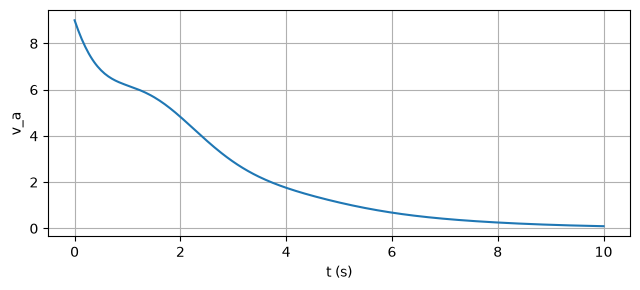

In [12]:
ts, ys = time_samples(c4, 'v_a', 10, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('v_a'); plt.grid(True); plt.tight_layout()

## 5. Three-phase wye-delta with line impedances

Alexander and Sadiku's Example 12.11, the balanced wye-delta with line impedances (Lesson 9 solves it too), the sources typed the way the book prints them. One AC call: aa(iraa) reads 2.350 at -36.20 degrees, and the Evaluate line's load line voltage 169.94 at 30.81 degrees. The exemplary part is what is absent: no wye-delta transformation, no single-phase equivalent.

![The circuit of Three-phase wye-delta with line impedances](https://learn.symbulator.com/assets/circuit/as7e1211.png)

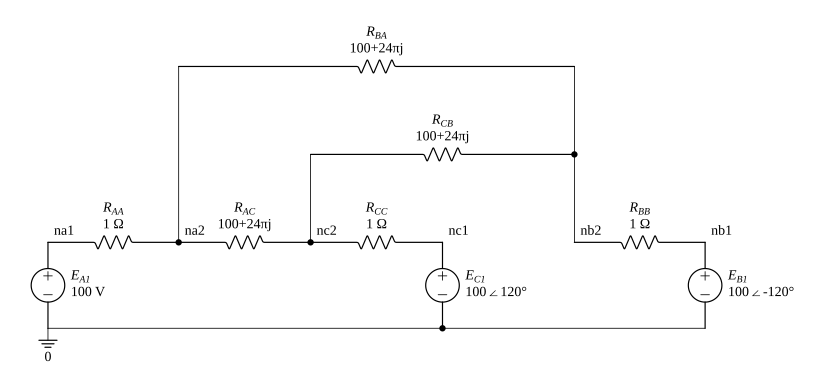

In [13]:
c5 = '''
ea1,na1,0,100
eb1,nb1,0,(100∠-120°)
ec1,nc1,0,(100∠120°)
raa,na1,na2,1
rbb,nb1,nb2,1
rcc,nc1,nc2,1
rac,na2,nc2,100+24*pi*j
rcb,nc2,nb2,100+24*pi*j
rba,nb2,na2,100+24*pi*j
'''
draw(c5)

In [14]:
r5 = ac(c5, omega='omega')
r5.rounded(4)

Result(domain='ac')
  ap_ea1 = -94.82
  ap_eb1 = -94.82
  ap_ec1 = -94.82
  ap_raa = 2.762
  ap_rac = 92.06
  ap_rba = 92.06
  ap_rbb = 2.762
  ap_rcb = 92.06
  ap_rcc = 2.762
  i_ea1 = -1.896 + 1.388*I
  i_eb1 = 2.15 + 0.9482*I
  i_ec1 = -0.254 - 2.336*I
  i_raa = 1.896 - 1.388*I
  i_rac = 0.5475 - 1.242*I
  i_rba = -1.349 + 0.1467*I
  i_rbb = -2.15 - 0.9482*I
  i_rcb = 0.8015 + 1.095*I
  i_rcc = 0.254 + 2.336*I
  p_ea1 = -94.82
  p_eb1 = -94.82
  p_ec1 = -94.82
  p_raa = 2.762
  p_rac = 92.06
  p_rba = 92.06
  p_rbb = 2.762
  p_rcb = 92.06
  p_rcc = 2.762
  q_ea1 = -69.41
  q_eb1 = -69.41
  q_ec1 = -69.41
  q_raa = 0
  q_rac = 69.41
  q_rba = 69.41
  q_rbb = 0
  q_rcb = 69.41
  q_rcc = 0
  s_ea1 = -94.82 - 69.41*I
  s_eb1 = -94.82 - 69.41*I
  s_ec1 = -94.82 - 69.41*I
  s_raa = 2.762
  s_rac = 92.06 + 69.41*I
  s_rba = 92.06 + 69.41*I
  s_rbb = 2.762
  s_rcb = 92.06 + 69.41*I
  s_rcc = 2.762
  v_ea1 = 100.0
  v_eb1 = -50.0 - 86.6*I
  v_ec1 = -50.0 + 86.6*I
  v_na1 = 100.0
  v_na2 = 98

In [15]:
evaluate(r5, 'vna2-vnb2')

145.953144123743 + 87.0425221594954*I

## 6. The ideal transformer, symbolically

From the teaching corpus, after AS7's Figure 13.33 (Lesson 10 has it too): everything in the description is a name. The Thevenin equivalent at the primary derives the referred-source and referred-impedance identities every machines course teaches -- vth = vs2/n and req = z2/n^2. When the answer to a symbolic question is the textbook's own theorem, the simulator has produced knowledge in the form the student is supposed to carry away.

![The circuit of The ideal transformer, symbolically](https://learn.symbulator.com/assets/circuit/as7f1333.png)

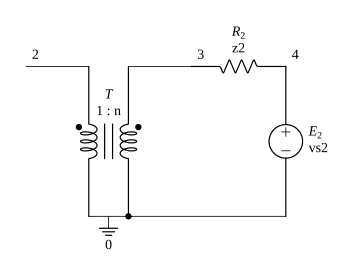

In [16]:
c6 = '''
t,2,3,1,n
r2,3,4,z2
e2,4,0,vs2
'''
draw(c6)

In [17]:
r6 = th(c6, '2', '0', domain='dc')
r6

TheveninResult(domain='dc', vth=vs2/n, ino=n*vs2/z2, req=z2/n**2, pmax=vs2**2/(4*z2))

## 7. Coupled coils with initial conditions

Composed for the monograph: two identical coupled coils, each closed on its own resistor, no sources anywhere -- the primary carries 1 A at t = 0 and the secondary is at rest. One TR call: il1 = (e^-t + e^-3t)/2 and il2 = (e^-t - e^-3t)/2, the circuit's common and differential modes in plain sight. Energy handed across the coupling and returned to heat, the whole story in two exponentials.

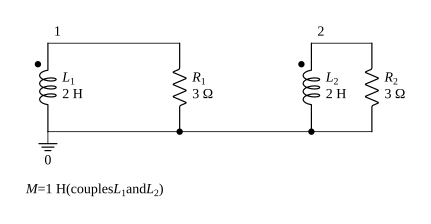

In [18]:
c7 = '''
l1,1,0,2,1
r1,1,0,3
l2,2,0,2
r2,2,0,3
m,l1,l2,1
'''
draw(c7)

In [19]:
r7 = tr(c7)
r7

Result(domain='tr')
  i_l1 = (exp(2*t) + 1)*exp(-3*t)/2
  i_l2 = (exp(2*t) - 1)*exp(-3*t)/2
  i_r1 = -(exp(2*t) + 1)*exp(-3*t)/2
  i_r2 = (1 - exp(2*t))*exp(-3*t)/2
  v_1 = -(3*exp(2*t) + 3)*exp(-3*t)/2
  v_2 = 3*(1 - exp(2*t))*exp(-3*t)/2

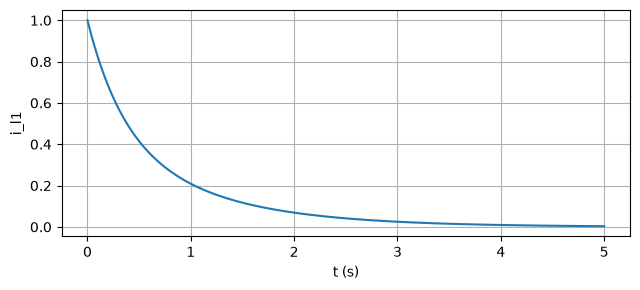

In [20]:
ts, ys = time_samples(c7, 'i_l1', 5, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('i_l1'); plt.grid(True); plt.tight_layout()

## 8. Two op-amps, all symbols

After Bobrow's Example 3.3 (Lesson 5 solves it too): a two-op-amp summing cascade in which every conductance is a symbol. The Evaluate line reads the gain, vo/vs = (g1-g2)/(g3-g4) -- a difference of conductances over a difference of conductances, so the circuit's structure is read directly off the expression. The single most persuasive demonstration of what Symbulator is for.

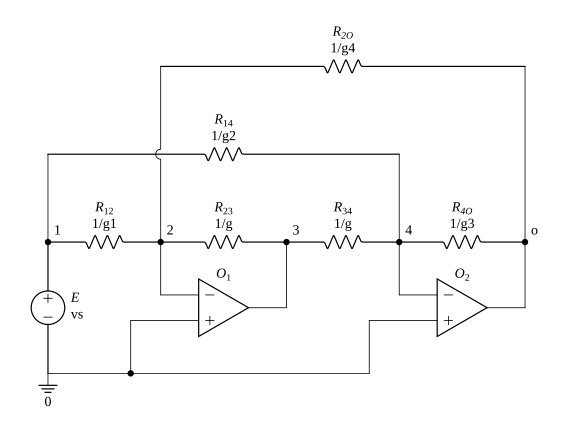

In [21]:
c8 = '''
e,1,0,vs
r12,1,2,1/g1
r14,1,4,1/g2
r23,2,3,1/g
r34,3,4,1/g
r2o,2,o,1/g4
r4o,4,o,1/g3
o1,0,2,3
o2,0,4,o
'''
draw(c8)

In [22]:
r8 = dc(c8)
r8

Result(domain='dc')
  i_e = vs*(-g1 - g2)
  i_o1 = 2*vs*(-g1*g3 + g2*g4)/(g3 - g4)
  i_o2 = vs*(g1*g3 + g1*g4 - g2*g3 - g2*g4)/(g3 - g4)
  i_r12 = g1*vs
  i_r14 = g2*vs
  i_r23 = vs*(g1*g3 - g2*g4)/(g3 - g4)
  i_r2o = g4*vs*(-g1 + g2)/(g3 - g4)
  i_r34 = vs*(-g1*g3 + g2*g4)/(g3 - g4)
  i_r4o = g3*vs*(-g1 + g2)/(g3 - g4)
  p_e = vs**2*(-g1 - g2)
  p_o1 = -2*vs**2*(g1*g3 - g2*g4)**2/(g*(g3 - g4)**2)
  p_o2 = -vs**2*(g1 - g2)*(g1*g3 + g1*g4 - g2*g3 - g2*g4)/(g3 - g4)**2
  p_r12 = g1*vs**2
  p_r14 = g2*vs**2
  p_r23 = vs**2*(g1*g3 - g2*g4)**2/(g*(g3 - g4)**2)
  p_r2o = g4*vs**2*(g1 - g2)**2/(g3 - g4)**2
  p_r34 = vs**2*(g1*g3 - g2*g4)**2/(g*(g3 - g4)**2)
  p_r4o = g3*vs**2*(g1 - g2)**2/(g3 - g4)**2
  r_e = 1/(g1 + g2)
  v_1 = vs
  v_2 = 0
  v_3 = vs*(-g1*g3 + g2*g4)/(g*(g3 - g4))
  v_4 = 0
  v_e = vs
  v_o = vs*(g1 - g2)/(g3 - g4)
  v_r12 = vs
  v_r14 = vs
  v_r23 = vs*(g1*g3 - g2*g4)/(g*(g3 - g4))
  v_r2o = vs*(-g1 + g2)/(g3 - g4)
  v_r34 = vs*(-g1*g3 + g2*g4)/(g*(g3 - g4))
  v_r4o = vs*(

In [23]:
evaluate(r8, 'vo/vs')

(g1 - g2)/(g3 - g4)